In [ ]:
### Created by Myongin Oh
### Last updated on Aug 23, 2025

In [ ]:
### STEP 0. Import libraries
import numpy as np
import pandas as pd
from skfeature.function.similarity_based import fisher_score
import matplotlib.pyplot as plt
import gc
import seaborn as sns
import kneed

In [2]:
### STEP 1. Load input data
dfReduced = pd.read_csv('output_dist_res_with_class_post_var.csv')

In [3]:
X = dfReduced.drop('class', axis=1)

In [4]:
df_scores_sorted = pd.read_csv('fisher_scores_dfReduced_descending.csv')

In [7]:
from kneed import KneeLocator

x = range(len(df_scores_sorted))

# Find the knee point
kneedle  = KneeLocator(x, df_scores_sorted['fs'], S=200, curve='convex', direction='decreasing')
knee_point = kneedle.knee
knee_value = kneedle.knee_y

print(f"The knee point is at x (nFeat) = {knee_point}, and score of: {kneedle.knee_y}")

The knee point is at x (nFeat) = 1766, and score of: 0.2194907830689325


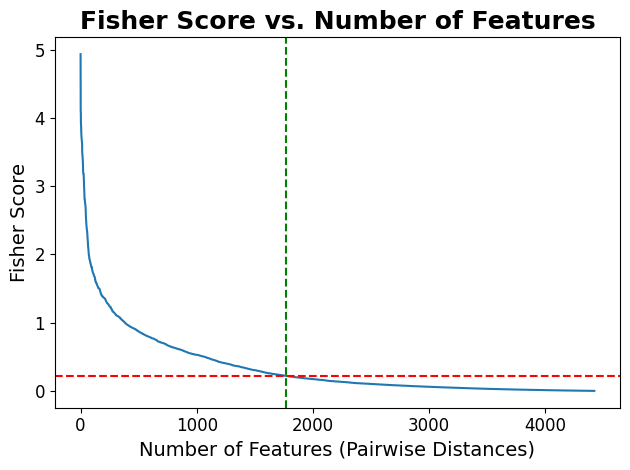

In [8]:
plt.plot(range(len(df_scores_sorted)), df_scores_sorted['fs'], label='Fisher Score')

plt.xlabel('Number of Features (Pairwise Distances)', fontsize=14)
plt.ylabel('Fisher Score', fontsize=14)
plt.title('Fisher Score vs. Number of Features', fontweight='bold', fontsize=18)
# Edit according to new threshold
plt.axvline(x=knee_point, color='g', linestyle='--')
plt.axhline(y=kneedle.knee_y, color='r', linestyle='--')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
#plt.savefig('./fisher_knee_feature_num.pdf', dpi=300)
plt.show()

In [9]:
dfidx = pd.read_csv('fisher_indices_dfReduced.csv', header=None, usecols=[1], names=["idx"])
dfidx

,idx
0,3751
1,3681
2,3832
3,3842
4,3820
...,...
4420,203
4421,4110
4422,4142
4423,1359


In [10]:
nFeat = kneedle.knee
idx = dfidx['idx'].to_list()
reduced_X = X.iloc[:, idx[0:nFeat]]
reduced_X

,res74.76,res72.76,res76.94,res76.104,res76.82,res76.90,res76.92,res76.106,res76.120,res76.118,...,res7.73,res29.81,res56.58,res27.46,res20.51,res15.17,res35.78,res7.57,res41.84,res21.123
0,7.737031,10.174965,21.078329,12.126591,12.532634,28.934854,22.712179,13.173096,17.889293,19.708840,...,23.981876,18.768484,10.463677,42.873231,18.293983,8.474514,19.878094,19.922207,19.862745,8.895487
1,7.627539,9.558457,21.241367,11.713173,12.051415,29.258166,23.301604,13.309355,17.707458,19.861900,...,26.081640,19.367964,10.511629,42.970580,17.863180,7.809893,20.320841,18.813751,19.565538,9.131303
2,7.584590,9.591590,20.586367,11.823278,12.273200,28.823700,23.199539,12.677116,17.570004,19.283007,...,25.661464,20.109298,9.626133,43.369332,17.708346,7.553901,20.505739,19.239928,19.689361,9.027367
3,7.618044,9.716299,20.848681,12.196202,11.884677,28.583090,23.017894,13.067129,18.362952,20.344056,...,25.849864,19.194404,9.750490,43.614514,18.188495,7.758495,20.054960,19.239650,20.970740,9.291110
4,7.880508,9.529382,20.398664,12.257854,11.838811,28.376116,22.432577,12.771427,17.676617,19.510499,...,26.331399,19.368367,9.829792,44.350404,18.491655,8.386994,20.491529,19.844709,19.971112,10.168584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,9.153176,11.789269,23.277147,13.880523,14.681006,31.551680,25.709389,15.760102,20.437970,22.740003,...,24.220652,19.694453,10.391123,43.554906,18.185994,7.413246,19.512852,20.127508,19.468210,9.702083
29996,8.993327,12.064141,23.559181,13.881784,14.857078,31.440044,26.259881,16.093319,20.172686,22.120471,...,23.983927,18.665789,10.073537,42.612867,17.999379,7.091309,19.563489,20.075957,19.229029,9.901407
29997,8.852542,11.861429,23.813674,13.786725,14.743567,32.004195,26.210720,16.060328,20.614649,22.694239,...,23.866327,19.296014,9.891992,42.569025,17.519677,7.486828,21.238085,19.314145,18.967607,10.191065
29998,8.572662,11.728853,23.561118,13.961243,14.339868,31.496299,26.103818,16.278452,20.808361,22.851659,...,24.364885,19.416179,9.895519,42.294952,17.516908,7.871596,19.876876,20.349051,19.178917,9.567765


In [12]:
dfFinal = reduced_X

classList = dfReduced['class'].to_numpy()
dfFinal.to_csv('dfFinal_1766feats.csv', encoding='utf-8', index=False)